In [1]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = "cpu"

In [29]:
import random

class Sequence(Dataset):
    def __init__(self, num_samples, V, K, L, task=2):
        self.num_samples = num_samples
        self.V = V
        self.K = K
        self.L = L
        self.task = task
        self.marker = V + 1 
        
    def __len__(self):
        return self.num_samples
        
    def __getitem__(self, idx):
        min_len = int(0.9 * self.L)
        seq_len = random.randint(min_len, self.L)

        seq = torch.randint(1, self.V + 1, (seq_len,))
        
        max_pos = seq_len - self.K - 2
        if max_pos < 0:
            max_pos = 0 
            
        marker_pos = random.randint(0, max_pos)
        seq[marker_pos] = self.marker
        
        if self.task == 1:
            target = seq[marker_pos + 1].clone()
        elif self.task == 2:
            target = seq[marker_pos + self.K].clone()
        elif self.task == 3:
            z = seq[marker_pos + self.K]
            target = (seq == z).sum().clone()
        return seq, target

In [4]:
from torch.nn.utils.rnn import pad_sequence

In [5]:
def collate_fn(batch):
    sequences, targets = zip(*batch)
    padded_seqs = pad_sequence(sequences, batch_first=True, padding_value=0)
    targets = torch.stack(targets)
    
    return padded_seqs, targets

In [6]:
V = 5
k = 1
L = 10
num_samples = 1000 
batch_size = 3

In [7]:
dataset = Sequence(num_samples=num_samples, V=V, K=k, L=L)

In [8]:
train_size = int(0.8 * len(dataset))
test_size = int(len(dataset) - train_size)
train_data, test_data = torch.utils.data.random_split(dataset, [train_size, test_size])

In [9]:
dataloader_train = DataLoader(train_data, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
dataloader_test = DataLoader(test_data, batch_size=batch_size, collate_fn=collate_fn)

In [10]:
from torch import nn

In [24]:
class LSTM(nn.Module):
    def __init__(self, vocab_size: int = 5 + 2, hidden_size: int = 100, embedding_dim: int = 16):
        super().__init__()
        self.vocab_size = vocab_size + 2
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(self.vocab_size, embedding_dim=embedding_dim)
        gate_size = embedding_dim + hidden_size
        
        self.w_f = nn.Linear(gate_size, hidden_size)
        self.w_i = nn.Linear(gate_size, hidden_size)
        self.w_o = nn.Linear(gate_size, hidden_size)
        self.w_c = nn.Linear(gate_size, hidden_size)

        self.fc_out = nn.Linear(hidden_size, self.vocab_size)
        
    def forward(self, x):
        batch_size, seq_len = x.size()
        h_t = torch.zeros(batch_size, self.hidden_size, device=x.device)
        c_t = torch.zeros(batch_size, self.hidden_size, device=x.device)

        embedded = self.embedding(x)

        for t in range(seq_len):
            x_t = embedded[:, t, :]
            combined = torch.cat((x_t, h_t), dim=1)
            
            f_t = torch.sigmoid(self.w_f(combined))
            i_t = torch.sigmoid(self.w_i(combined))
            c_t_ = torch.tanh(self.w_c(combined))
            o_t = torch.sigmoid(self.w_o(combined))

            c_t = f_t * c_t + i_t * c_t_
            h_t = o_t * torch.tanh(c_t)
        
        out = self.fc_out(h_t)
        
        return out

In [12]:
from torch.optim import AdamW

In [13]:
import mlflow

In [14]:
model = LSTM(vocab_size=V).to(device)
optim = AdamW(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

In [15]:
num_epochs = 10

In [16]:
import random

In [17]:
LSTM.__name__

'LSTM'

In [19]:
import torch.nn.functional as F

In [67]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, mean_absolute_error
import time

In [54]:
def calculate_metrics(y_true, y_pred, y_prob=None, is_regression=False):
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred, average='macro') 
    }
    if y_prob is not None:
        try:
            unique_classes = np.unique(y_true)
            y_prob_filtered = y_prob[:, unique_classes]
            
            row_sums = y_prob_filtered.sum(axis=1, keepdims=True)
            y_prob_filtered = y_prob_filtered / (row_sums + 1e-9) 
            
            if len(unique_classes) == 2:
                metrics['AUROC'] = roc_auc_score(y_true, y_prob_filtered[:, 1])
            elif len(unique_classes) > 2:
                metrics['AUROC'] = roc_auc_score(y_true, y_prob_filtered, multi_class='ovr')
            else:
                metrics['AUROC'] = np.nan
                
        except Exception as e:
            metrics['AUROC'] = np.nan
            
    if is_regression:
        metrics['MAE'] = mean_absolute_error(y_true, y_pred)
        
    return metrics

In [60]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def visualyse_results(results_df: pd.DataFrame, model_name: str, task_name: str, include_mae: bool = False):
    metrics_to_plot = ['Accuracy', 'F1', 'AUROC']
    if include_mae:
        metrics_to_plot.append('MAE')
        
    fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(6 * len(metrics_to_plot), 5))
    fig.suptitle(f'Модель: {model_name} | Задача: {task_name}', fontsize=16, y=1.05)
    
    if len(metrics_to_plot) == 1:
        axes = [axes] 
        
    for i, metric in enumerate(metrics_to_plot):
        if metric not in results_df.columns:
            axes[i].set_visible(False) 
            continue
            
        pivot_data = results_df.pivot_table(index='k', columns='L', values=metric, aggfunc='mean')
        
        if pivot_data.empty or pivot_data.isna().all().all():
            axes[i].set_visible(False) 
            continue
        
        cmap = "YlGnBu_r" if metric == 'MAE' else "YlGnBu"
        
        sns.heatmap(pivot_data, annot=True, fmt=".3f", cmap=cmap, ax=axes[i], 
                    cbar_kws={'label': metric}, linewidths=.5)
        
        axes[i].set_title(f'Метрика: {metric}')
        axes[i].set_xlabel('L (Длина/Ось X)')
        axes[i].set_ylabel('k (Ось Y)')
        axes[i].invert_yaxis() 

    plt.tight_layout()
    plt.show()

In [68]:
import torch.nn.functional as F

def train_model(model: torch.nn.Module, epochs: int, optim: torch.optim.Optimizer, criterion, batch_size, task: int = 2, **dataset_kwargs):
    dataset = Sequence(task=task, **dataset_kwargs)

    train_losses, test_losses = [], []
    
    train_size = int(0.8 * len(dataset))
    test_size = int(len(dataset) - train_size)
    train_data, test_data = torch.utils.data.random_split(dataset, [train_size, test_size])
    
    dataloader_train = DataLoader(train_data, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
    dataloader_test = DataLoader(test_data, batch_size=batch_size, collate_fn=collate_fn)
    
    run_name = f"{type(model).__name__}_Task{task}_L{dataset_kwargs.get('L')}_K{dataset_kwargs.get('K')}"
    
    with mlflow.start_run(run_name=run_name):
        mlflow.log_params({
            "model_type": type(model).__name__,
            "learning_rate": optim.param_groups[0]['lr'],
            "task": task,
            **dataset_kwargs
        })
        
        for epoch in range(epochs):
            model.train()
            epoch_loss = 0.0
            
            for batch_x, batch_y in dataloader_train:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
    
                optim.zero_grad()
                outputs = model(batch_x)
                
                if task == 3:
                    predictions = outputs.squeeze(-1) 
                    loss = criterion(predictions, batch_y.float()) 
                else:
                    loss = criterion(outputs, batch_y)
                    
                loss.backward()
                optim.step()
                epoch_loss += loss.item()
    
            model.eval()
            all_preds, all_labels, all_probs = [], [], []
            test_loss = 0.0
            correct = 0
            total = 0
            total_inference_time = 0.0
            
            with torch.no_grad():
                for inputs, labels in dataloader_test:
                    inputs, labels = inputs.to(device), labels.to(device)
                    start_time = time.perf_counter()
                    outputs = model(inputs)
                    end_time = time.perf_counter()

                    total_inference_time += (end_time - start_time)
                    
                    if task == 3:
                        predictions = outputs.squeeze(-1)
                        batch_test_loss = criterion(predictions, labels.float())
                        
                        predicted = torch.round(predictions)
                        probs = torch.zeros((labels.size(0), 2)) 
                    else:
                        batch_test_loss = criterion(outputs, labels)
                        probs = F.softmax(outputs, dim=1)
                        _, predicted = torch.max(outputs.data, 1)
                        
                    test_loss += batch_test_loss.item()
                    
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()
                    
                    all_preds.extend(predicted.cpu().numpy())
                    all_labels.extend(labels.cpu().numpy())
                    all_probs.extend(probs.cpu().numpy())
                    
            accuracy = correct / total
            avg_train_loss = epoch_loss / len(dataloader_train)
            avg_test_loss = test_loss / len(dataloader_test)
            
            train_losses.append(avg_train_loss)
            test_losses.append(avg_test_loss)
            
            mlflow.log_metric("test_accuracy", accuracy, step=epoch)
            mlflow.log_metric("train_loss", avg_train_loss, step=epoch)
            mlflow.log_metric("test_loss", avg_test_loss, step=epoch)
            
        try:
            final_metrics = calculate_metrics(all_labels, all_preds, y_prob=np.array(all_probs), is_regression=(task==3))
            avg_batch_time = total_inference_time / len(dataloader_test)
            final_metrics['Avg_Batch_Time'] = avg_batch_time
            mlflow.log_metrics({f"final_{k}": v for k, v in final_metrics.items()})
        except Exception as e:
            print(f"Ошибка при расчете финальных метрик: {e}")
            final_metrics = {'Accuracy': accuracy} 
        
        return final_metrics

In [44]:
with mlflow.start_run(run_name="LSTM_baseline"):
    mlflow.log_params({
        "model_type": "LSTM",
        "vocab_size": V,
        "k_shift": k,
        "max_length": L,
        "learning_rate": 1e-3
    })
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        
        for batch_x, batch_y in dataloader_train:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            optim.zero_grad()
            if task == 3:
                predictions = outputs.squeeze(-1)
                loss = criterion(predictions, batch_y.float()) 
            else:
                loss = criterion(outputs, batch_y)
            loss.backward()
            optim.step()
            epoch_loss += loss.item()


        model.eval()
        test_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in dataloader_test:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                test_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        avg_train_loss = epoch_loss / len(dataloader_train)
        avg_test_loss = test_loss / len(dataloader_test)
        train_losses.append(avg_train_loss)
        test_losses.append(avg_test_loss)
        mlflow.log_metric("train_loss", avg_train_loss, step=epoch)
        mlflow.log_metric("test_loss", avg_test_loss, step=epoch)

In [41]:
train_model(model=model, optim=optim, criterion=criterion, epochs=10, batch_size = 3, V = 5,K = 1,L = 10,num_samples = 1000)

In [25]:
class GRU(nn.Module):
    def __init__(self, vocab_size: int = 5 + 2, hidden_size: int = 100, embedding_dim: int = 16):
        super().__init__()
        self.hidden_size = hidden_size
        self.vocab_size = vocab_size + 2
        self.embedding_dim = embedding_dim
        
        self.embeddings = nn.Embedding(self.vocab_size, embedding_dim=self.embedding_dim)
        
        gate_size = self.embedding_dim + self.hidden_size
        
        self.w_r = nn.Linear(gate_size, self.hidden_size)
        self.w_u = nn.Linear(gate_size, self.hidden_size)
        self.w_h = nn.Linear(gate_size, self.hidden_size)
        self.fc_out = nn.Linear(self.hidden_size, self.vocab_size)

    def forward(self, x):
        batch_size, seq_len = x.size()
        h_t = torch.zeros(batch_size, self.hidden_size, device=x.device)

        embedd = self.embeddings(x)
        for t in range(seq_len):
            x_t = embedd[:, t, :]
            combined = torch.cat((x_t, h_t), dim=1)

            r_t = torch.sigmoid(self.w_r(combined))
            u_t = torch.sigmoid(self.w_u(combined))

            combined_reset = torch.cat((x_t, r_t * h_t), dim=1)
            h_tilde = torch.tanh(self.w_h(combined_reset))

            h_t = (1 - u_t) * h_t + u_t * h_tilde

        return self.fc_out(h_t)

In [44]:
device

'cpu'

In [45]:
model = GRU(vocab_size=V).to(device)
optim = AdamW(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

In [46]:
train_model(model=model, optim=optim, criterion=criterion, epochs=10, batch_size = 3, V = 5,K = 1,L = 10,num_samples = 1000)

In [18]:
import math

In [50]:
import torch
import torch.nn as nn
import math

class Attention(nn.Module):
    def __init__(self, vocab_size: int = 5 + 2, seq_len: int = 100, embedding_dim: int = 32):
        super().__init__()
        self.seq_len = seq_len
        self.vocab_size = vocab_size + 2
        self.embedding_dim = embedding_dim
        
        self.embedding = nn.Embedding(self.vocab_size, embedding_dim, padding_idx=0) 
        self.pos_embedding = nn.Embedding(seq_len, embedding_dim)
        
        self.w_q = nn.Linear(embedding_dim, embedding_dim)
        self.w_k = nn.Linear(embedding_dim, embedding_dim)
        self.w_v = nn.Linear(embedding_dim, embedding_dim)
        self.scale = math.sqrt(embedding_dim)

        self.ffn = nn.Sequential(
            nn.Linear(embedding_dim, embedding_dim * 2),
            nn.ReLU(),
            nn.Linear(embedding_dim * 2, embedding_dim)
        )
        
        self.norm1 = nn.LayerNorm(embedding_dim)
        self.norm2 = nn.LayerNorm(embedding_dim)
        
        self.fc_out = nn.Linear(embedding_dim, self.vocab_size)
        
    def forward(self, x):
        batch_size, seq_len = x.size()

        positions = torch.arange(seq_len, device=x.device).unsqueeze(0).expand(batch_size, seq_len)
        
        x_emb = self.embedding(x) + self.pos_embedding(positions)

        q = self.w_q(x_emb)
        k = self.w_k(x_emb)
        v = self.w_v(x_emb)

        scores = torch.bmm(q, k.transpose(1, 2)) / self.scale
        
        pad_mask = (x == 0).unsqueeze(1).expand(batch_size, seq_len, seq_len)
        scores = scores.masked_fill(pad_mask, float('-inf'))

        weights = torch.softmax(scores, dim=-1)
        weights = weights.nan_to_num(0.0)

        context = torch.bmm(weights, v)
        
        context = self.norm1(x_emb + context) 
        
        ffn_out = self.ffn(context)
        context = self.norm2(context + ffn_out)
      
        valid_mask = (x != 0).unsqueeze(-1).float() 
        
        sum_context = (context * valid_mask).sum(dim=1) 
        
        valid_lengths = valid_mask.sum(dim=1).clamp(min=1.0) 
        
        pooled_context = sum_context / valid_lengths 

        out = self.fc_out(pooled_context)
        return out

In [51]:
model = Attention(vocab_size=V).to(device)
optim = AdamW(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

In [52]:
train_model(model=model, optim=optim, criterion=criterion, epochs=10, batch_size = 32, V = 5,K = 1,L = 10,num_samples = 10000)

{'Accuracy': 0.9975,
 'F1': 0.9974159874332829,
 'AUROC': np.float64(0.999996871990118)}

In [69]:
import pandas as pd
from tqdm.auto import tqdm 

V_val = 5
L_values = [10, 20, 30] 
k_values = [1, 3, 5]    
num_samples = 5000      
epochs = 10              
batch_size = 32
current_task = 2        

results = []
model_classes = [LSTM, GRU, Attention]

optim = AdamW(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

,Model,Task,L,k,Accuracy,F1,AUROC,Avg_Batch_Time
0,LSTM,2,10,1,1.000,1.000000,1.000000,0.001135
1,LSTM,2,10,3,1.000,1.000000,1.000000,0.001145
2,LSTM,2,10,5,1.000,1.000000,1.000000,0.001150
3,LSTM,2,20,1,1.000,1.000000,1.000000,0.002173
4,LSTM,2,20,3,1.000,1.000000,1.000000,0.002220
5,LSTM,2,20,5,1.000,1.000000,1.000000,0.002177
6,LSTM,2,10,1,1.000,1.000000,1.000000,0.001098
7,LSTM,2,10,3,1.000,1.000000,1.000000,0.001192
8,LSTM,2,10,5,1.000,1.000000,1.000000,0.001095
9,LSTM,2,20,1,1.000,1.000000,1.000000,0.002171


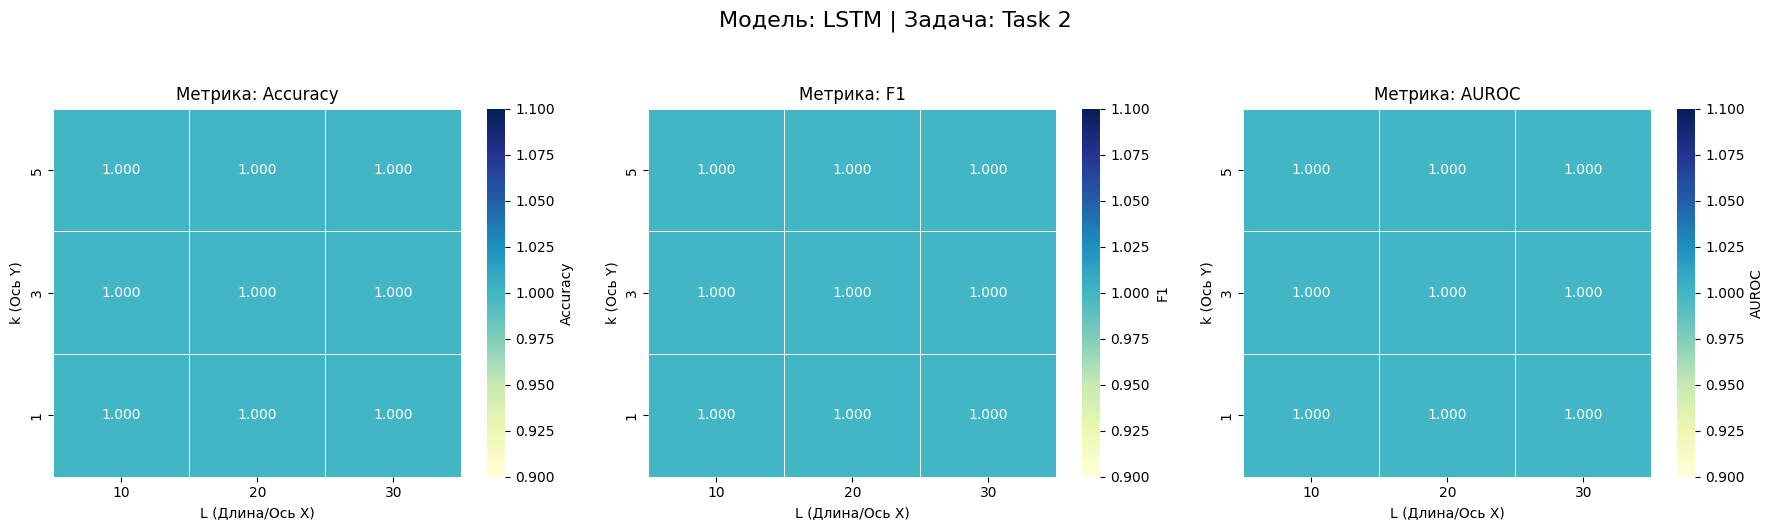

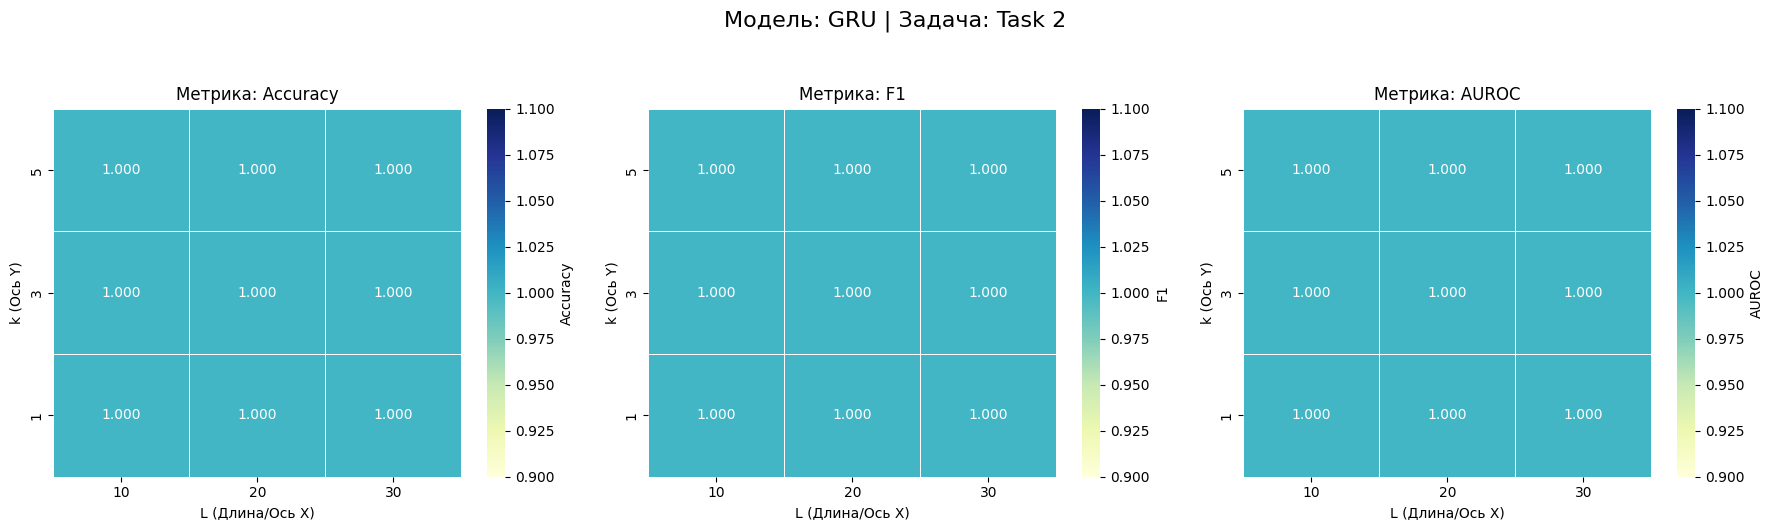

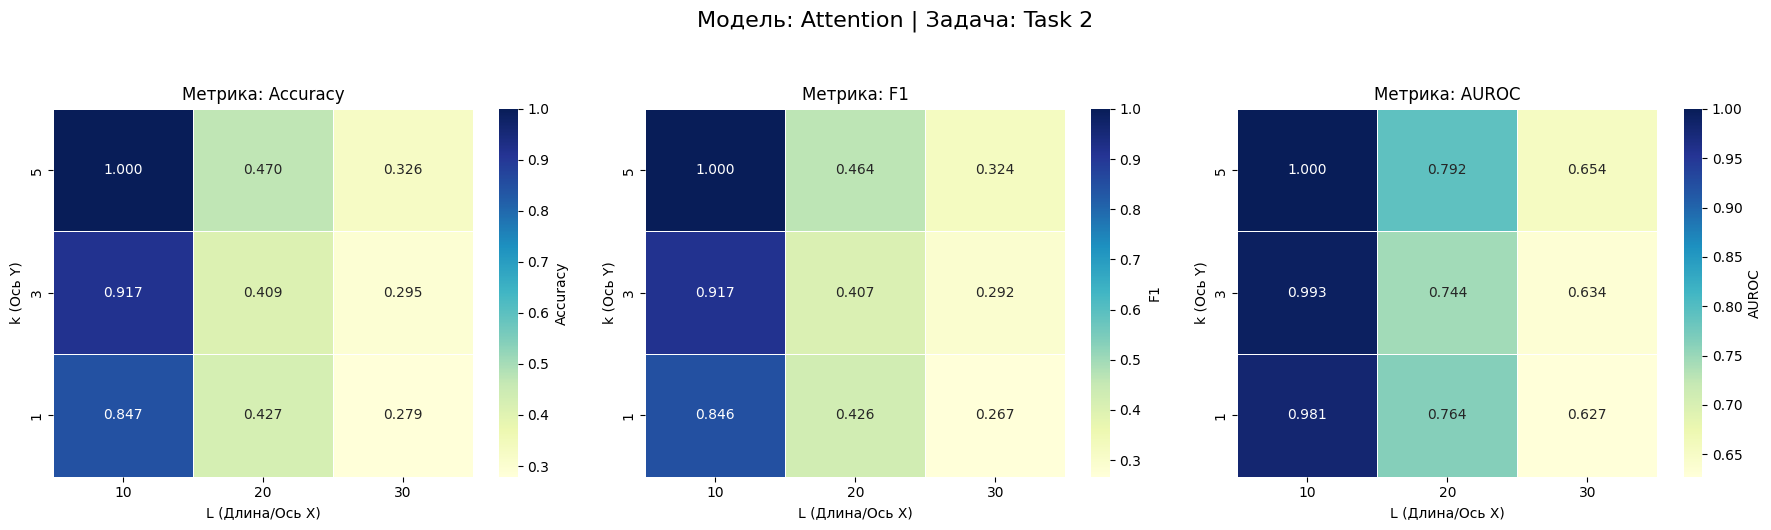

In [71]:
for model_class in model_classes:
    model_name = model_class.__name__
    for L_val in L_values:
        for k_val in k_values:
            min_len = int(0.9 * L_val)
            if k_val >= min_len - 2:
                continue
                
            if model_name == "Attention":
                model = model_class(vocab_size=V_val, seq_len=L_val).to(device)
            else:
                model = model_class(vocab_size=V_val).to(device)
                
            optim = torch.optim.AdamW(model.parameters(), lr=1e-3)
            criterion = torch.nn.CrossEntropyLoss()
            
            metrics = train_model(
                model=model, 
                epochs=epochs, 
                optim=optim, 
                criterion=criterion, 
                batch_size=batch_size, 
                task=current_task,      
                num_samples=num_samples, 
                V=V_val, 
                K=k_val, 
                L=L_val
            )
            
            row = {
                'Model': model_name,
                'Task': current_task,
                'L': L_val,
                'k': k_val
            }
            row.update(metrics) 
            results.append(row)

df_results = pd.DataFrame(results)

display(df_results)
for model_name in df_results['Model'].unique():
    model_data = df_results[df_results['Model'] == model_name]
    
    visualyse_results(
        results_df=model_data, 
        model_name=model_name, 
        task_name=f"Task {current_task}", 
        include_mae=(current_task == 3) 
    )

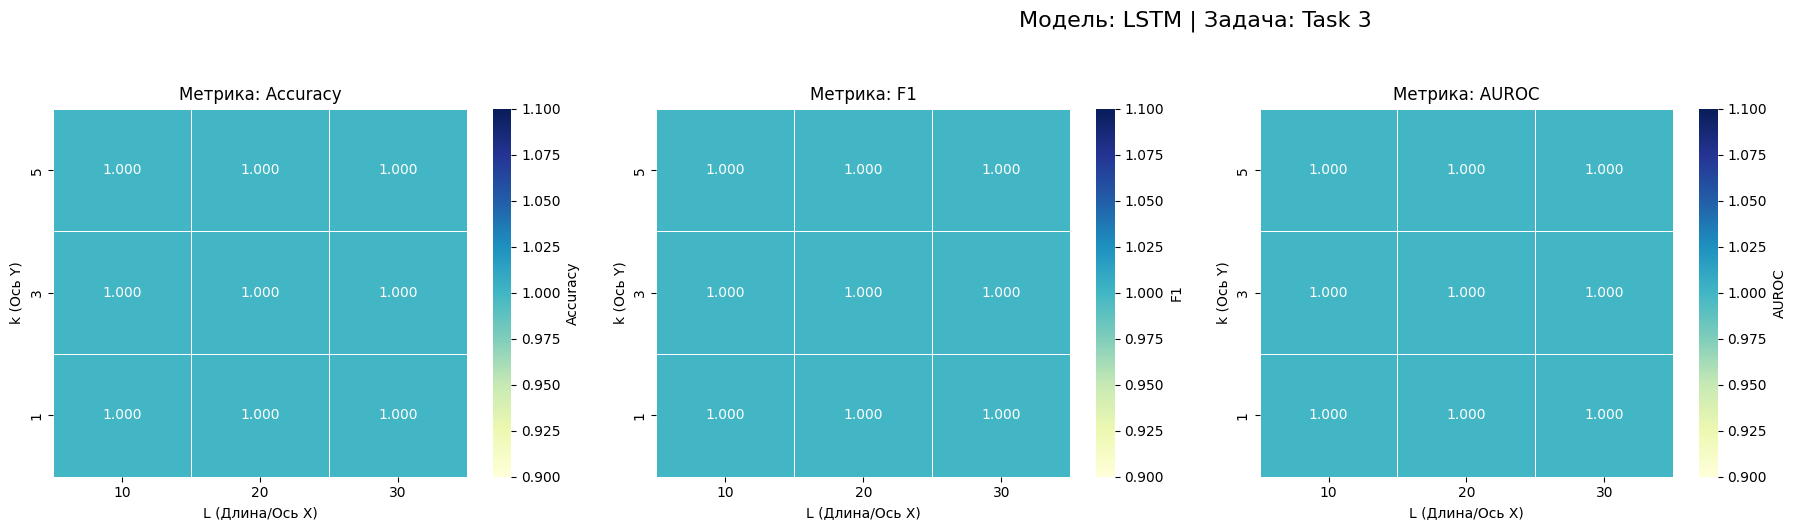

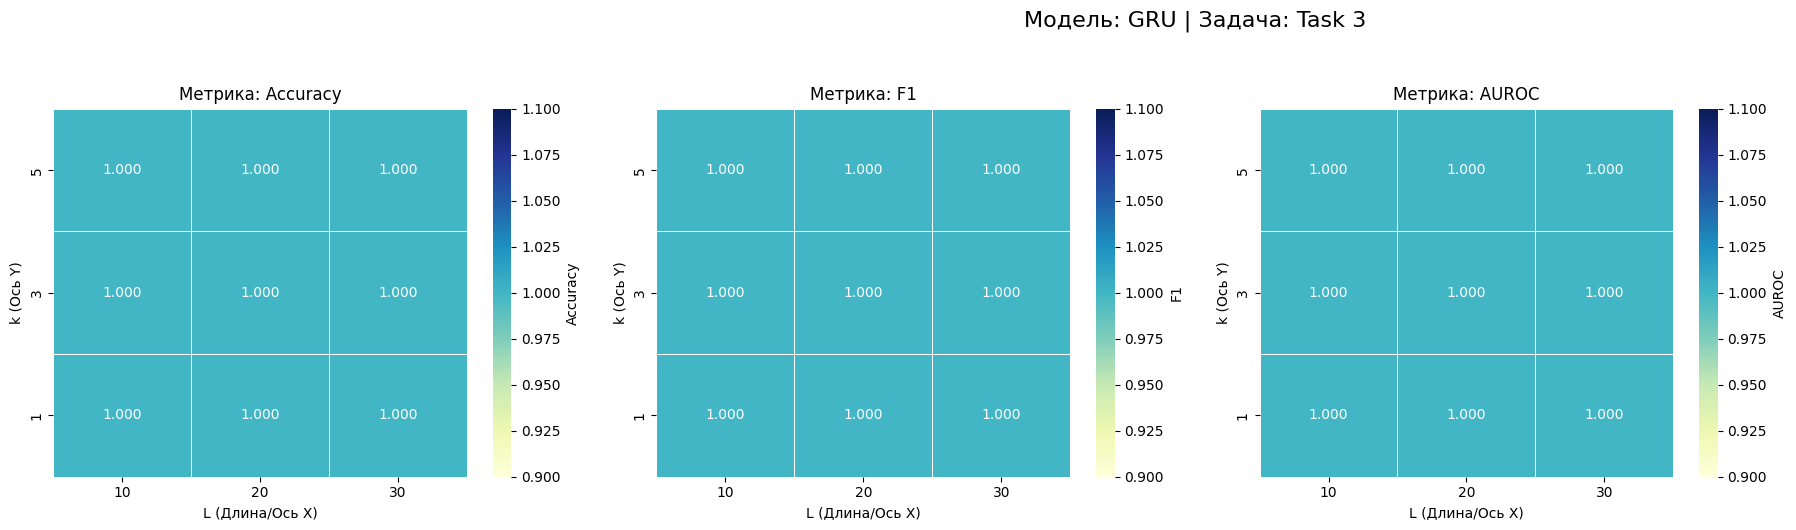

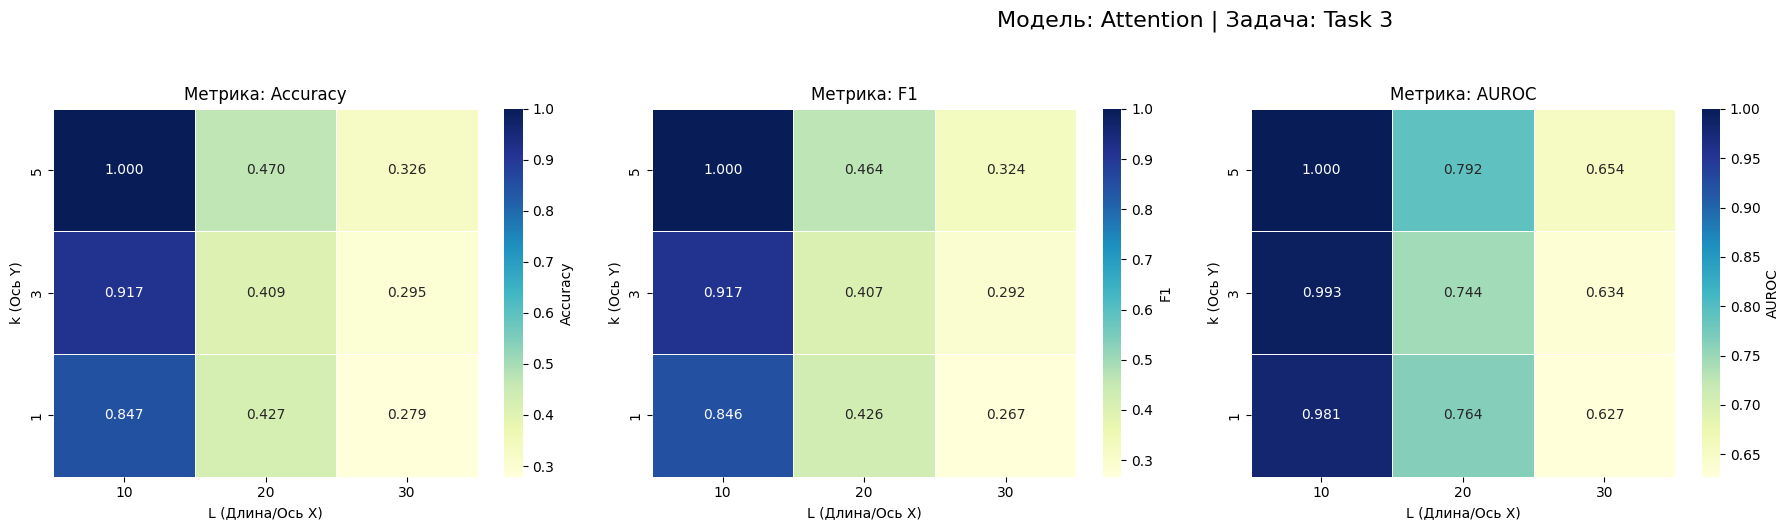

In [72]:
V_val = 5
L_values = [10, 20, 30]
k_values = [1, 3, 5]
num_samples = 1000 
epochs = 15
batch_size = 32

current_task = 3 

results = []
model_classes = [LSTM, GRU, Attention]

for model_class in model_classes:
    model_name = model_class.__name__
    for L_val in L_values:
        for k_val in k_values:
            min_len = int(0.9 * L_val)
            if k_val >= min_len - 2:
                continue
            if model_name == "Attention":
                model = model_class(vocab_size=V_val, seq_len=L_val).to(device)
            else:
                model = model_class(vocab_size=V_val).to(device)
                
            if current_task == 3:
                in_features = model.fc_out.in_features
                model.fc_out = nn.Linear(in_features, 1).to(device)
                
                criterion = nn.MSELoss()
            else:
                criterion = nn.CrossEntropyLoss()
                
            optim = torch.optim.AdamW(model.parameters(), lr=1e-3)
            
            metrics = train_model(
                model=model, 
                epochs=epochs, 
                optim=optim, 
                criterion=criterion, 
                batch_size=batch_size, 
                task=current_task,
                num_samples=num_samples, 
                V=V_val, 
                K=k_val, 
                L=L_val
            )
            
            row = {'Model': model_name, 'Task': current_task, 'L': L_val, 'k': k_val}
            row.update(metrics)
            results.append(row)

df_results_3 = pd.DataFrame(results)
df_results_3 = df_results.drop_duplicates(subset=['Model', 'L', 'k'], keep='last')

for model_name in df_results['Model'].unique():
    model_data = df_results[df_results['Model'] == model_name]
    visualyse_results(
        results_df=model_data, 
        model_name=model_name, 
        task_name=f"Task {current_task}", 
        include_mae=True  
    )

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_fixed_k_results(df_results, task_name):

    unique_k_values = df_results['k'].unique()
    
    for k_val in sorted(unique_k_values):
        df_k = df_results[df_results['k'] == k_val]
        
        if df_k.empty:
            continue
            
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f'Задача: {task_name} | Фиксированный сдвиг k = {k_val}', fontsize=14, y=1.05)
        
        sns.lineplot(data=df_k, x='L', y='Accuracy', hue='Model', 
                     marker='o', markersize=8, linewidth=2, ax=axes[0])
        axes[0].set_title('Зависимость Точности от Длины (L)')
        axes[0].set_xlabel('L (Максимальная длина последовательности)')
        axes[0].set_ylabel('Accuracy')
        axes[0].grid(True, linestyle='--', alpha=0.7)
        
        if 'Avg_Batch_Time' in df_k.columns:
            sns.lineplot(data=df_k, x='L', y='Avg_Batch_Time', hue='Model', 
                         marker='s', markersize=8, linewidth=2, ax=axes[1])
            axes[1].set_title('Среднее время предсказания батча')
            axes[1].set_xlabel('L (Максимальная длина последовательности)')
            axes[1].set_ylabel('Время (секунды)')
            axes[1].grid(True, linestyle='--', alpha=0.7)
        else:
            axes[1].set_title('Данные о времени отсутствуют')
            
        plt.tight_layout()
        plt.show()

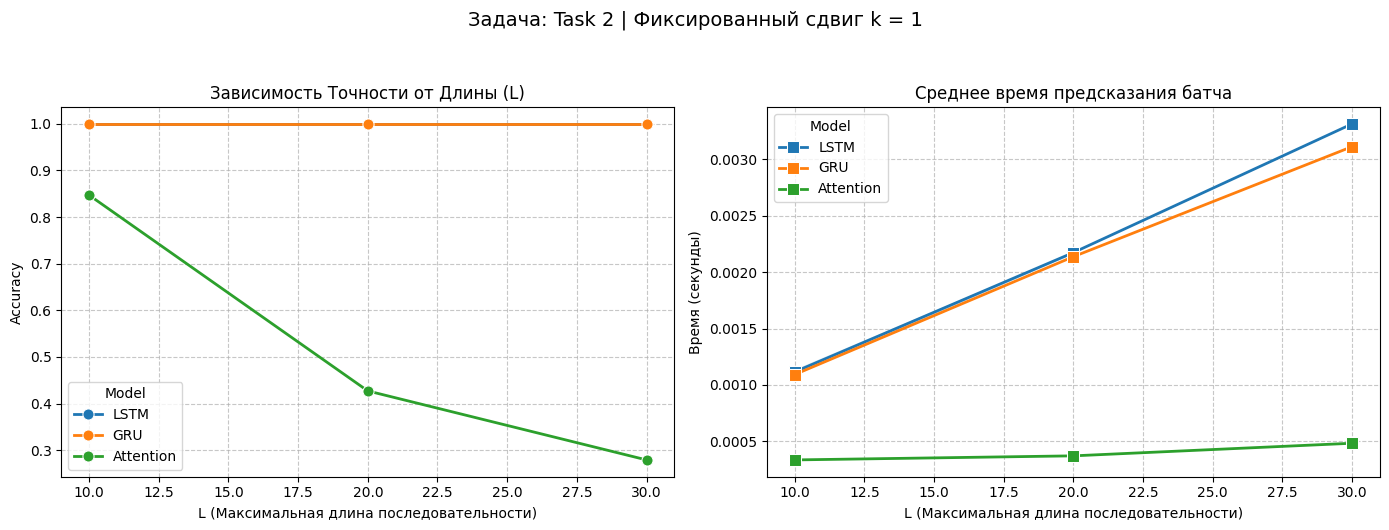

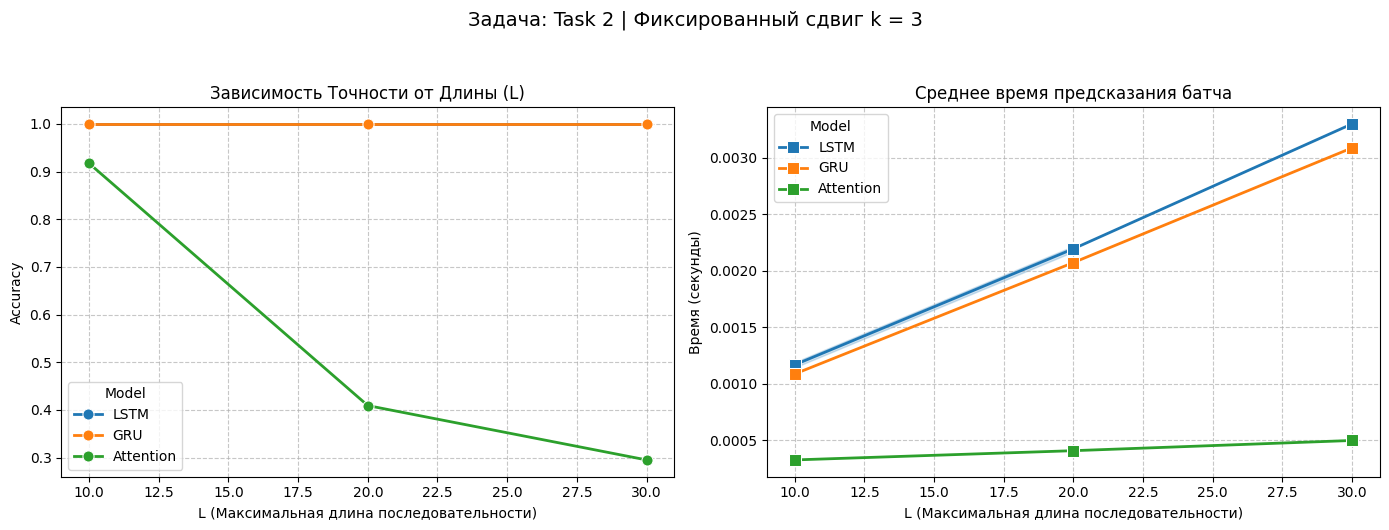

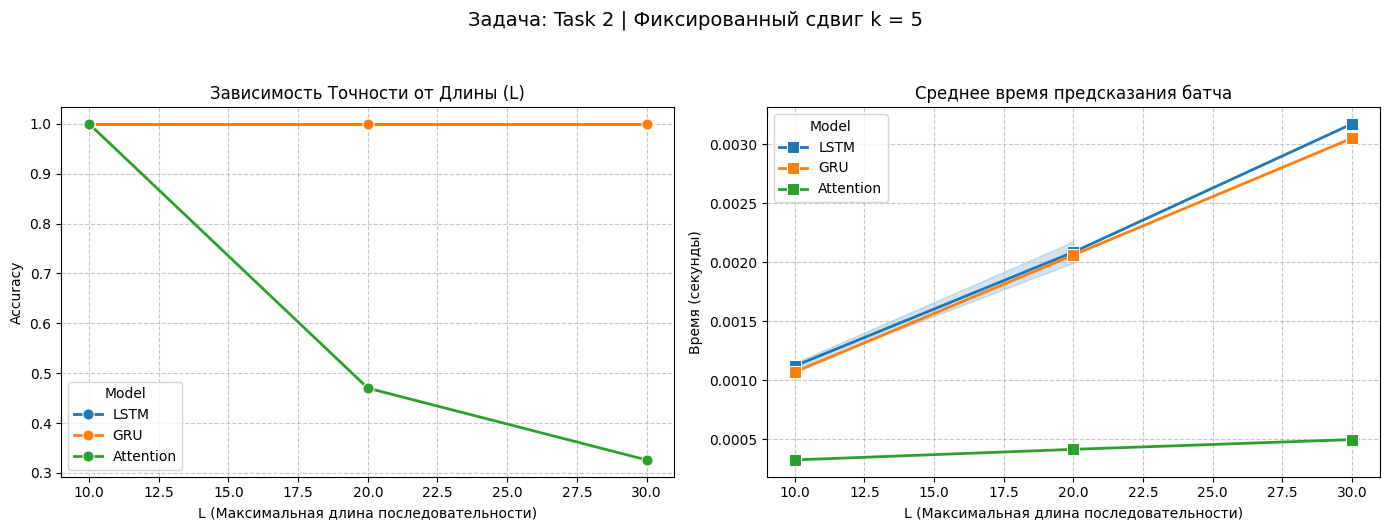

In [76]:
plot_fixed_k_results(df_results, task_name=f"Task 2")

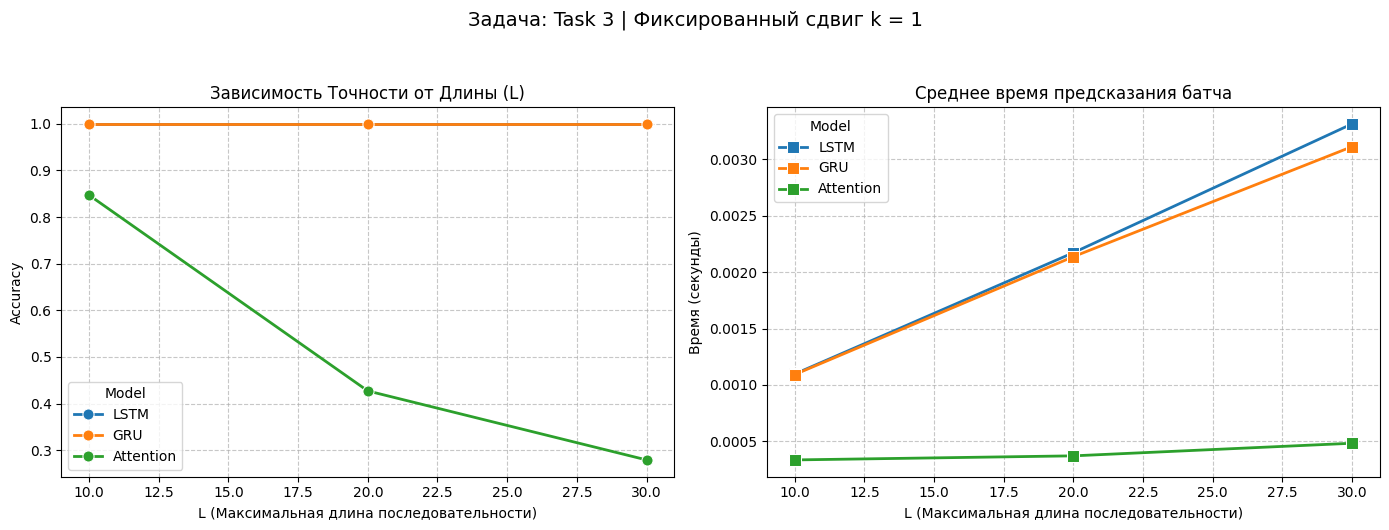

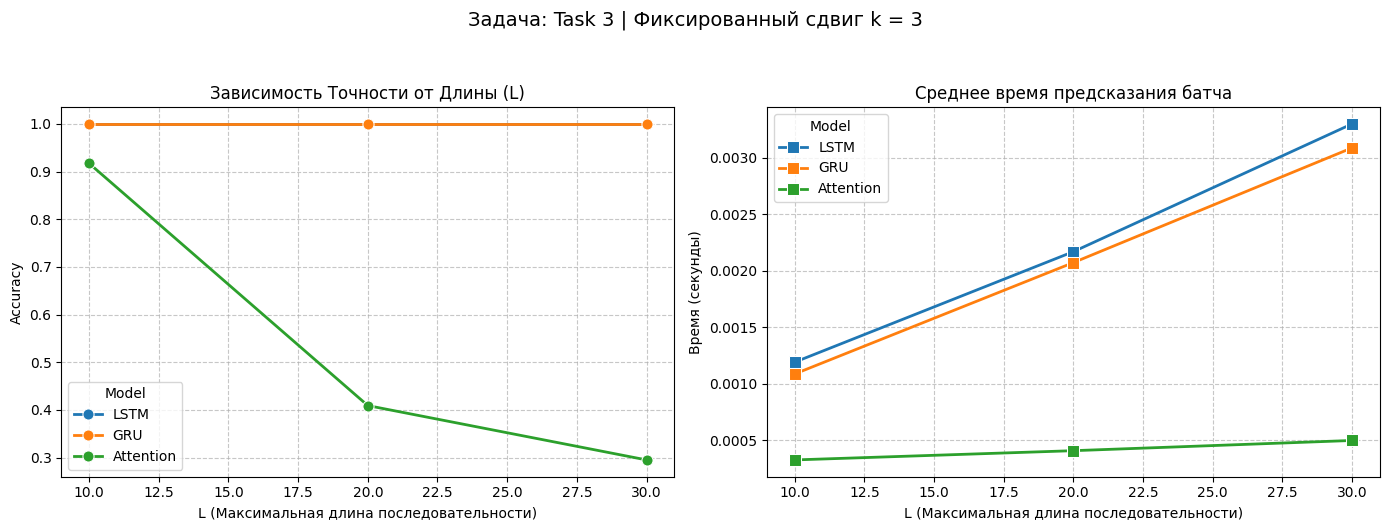

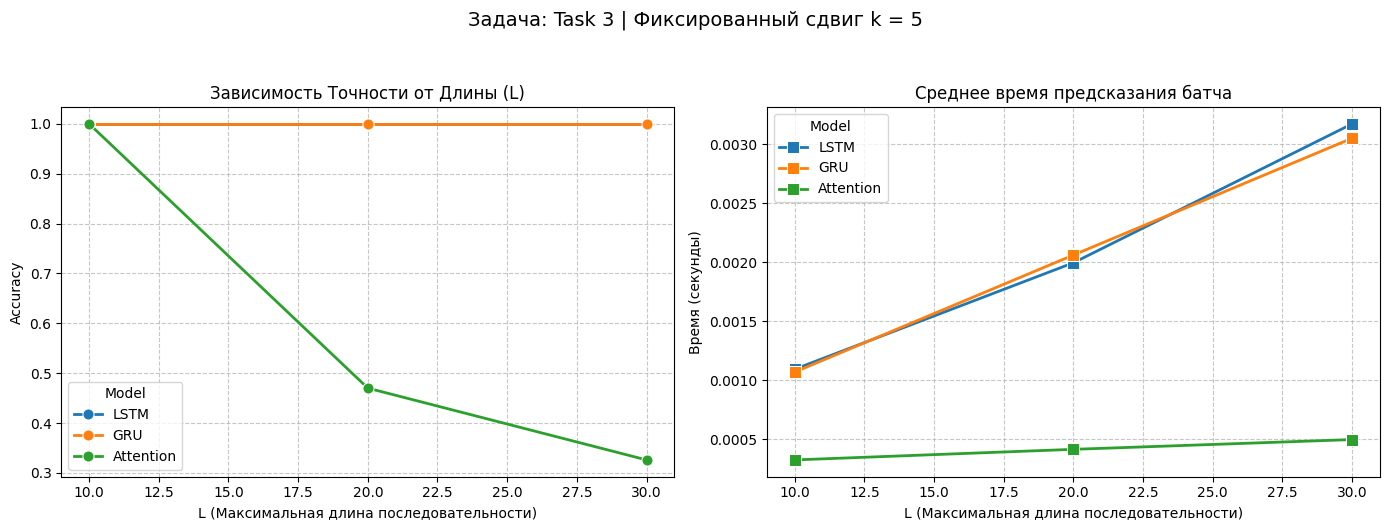

In [75]:
plot_fixed_k_results(df_results_3, task_name=f"Task {current_task}")